# Homework 1
## De Simone Guido
### Introduction


The project consists of analyzing the file 'DATI17' and creating a neural network, with at least 3 dense layers and 200,000 parameters.


### Preliminary operations

First of all, after loading the necessary libraries, I import the file and analyze it. So, I see how big it is, if there are some missing values and the type of variables.

In [ ]:
# I import the necessary libraries
print('Importing libraries...')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.metrics import AUC, Recall
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
print('All libraries imported succesfully.')

Importing libraries...
All libraries imported succesfully.


In [ ]:
# Import the file Excel
print('Importing the file...')
df = pd.read_excel('/content/drive/MyDrive/Laboratory of Machine Learning/Homework 2/DATI17.xlsx')
print('File uploaded succesfully.')
print()

Importing the file...
File uploaded succesfully.



In [ ]:
# I see the first rows of the dataset.
print("The first 10 rows of the data set are:")
df.head(10)

The first 10 rows of the data set are:


,Target,V1,V2,V3,V4,V5,V6,V7,Sex,AgeCategory,Race,V8,V9,GenHealth,V10,V11,V12,V13
0,No,16.60,Yes,No,No,3,30,No,Female,55-59,White,Yes,Yes,Very good,5,Yes,No,Yes
1,No,20.34,No,No,Yes,0,0,No,Female,80 or older,White,No,Yes,Very good,7,No,No,No
2,No,26.58,Yes,No,No,20,30,No,Male,65-69,White,Yes,Yes,Fair,8,Yes,No,No
3,No,24.21,No,No,No,0,0,No,Female,75-79,White,No,No,Good,6,No,No,Yes
4,No,23.71,No,No,No,28,0,Yes,Female,40-44,White,No,Yes,Very good,8,No,No,No
5,Yes,28.87,Yes,No,No,6,0,Yes,Female,75-79,Black,No,No,Fair,12,No,No,No
6,No,21.63,No,No,No,15,0,No,Female,70-74,White,No,Yes,Fair,4,Yes,No,Yes
7,No,31.64,Yes,No,No,5,0,Yes,Female,80 or older,White,Yes,No,Good,9,Yes,No,No
8,No,26.45,No,No,No,0,0,No,Female,80 or older,White,"No, borderline diabetes",No,Fair,5,No,Yes,No
9,No,40.69,No,No,No,0,0,Yes,Male,65-69,White,No,Yes,Good,10,No,No,No


In [ ]:
# Now, I define the target and all the explanatory variables. Then, I explore the file.
y = df['Target']
X = df.drop(columns = ['Target'])

In [ ]:
# I see how big this dataset is (in particular, how many rows and columns there are).
print("The target has: (rows, columns)")
print(y.shape)
print("The X has. (rows, columns)")
print(X.shape)

The target has: (rows, columns)
(319795,)
The X has. (rows, columns)
(319795, 17)


In [ ]:
# I use the function 'describe' to see other informations.
print("Here is some information about the variables:")
df.describe(include = 'all')

Here is some information about the variables:


,Target,V1,V2,V3,V4,V5,V6,V7,Sex,AgeCategory,Race,V8,V9,GenHealth,V10,V11,V12,V13
count,319795,319795.000000,319795,319795,319795,319795.00000,319795.000000,319795,319795,319795,319795,319795,319795,319795,319795.000000,319795,319795,319795
unique,2,NaN,2,2,2,NaN,NaN,2,2,13,6,4,2,5,NaN,2,2,2
top,No,NaN,No,No,No,NaN,NaN,No,Female,65-69,White,No,Yes,Very good,NaN,No,No,No
freq,292422,NaN,187887,298018,307726,NaN,NaN,275385,167805,34151,245212,269653,247957,113858,NaN,276923,308016,289976
mean,NaN,28.325399,NaN,NaN,NaN,3.37171,3.898366,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.097075,NaN,NaN,NaN
std,NaN,6.356100,NaN,NaN,NaN,7.95085,7.955235,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.436007,NaN,NaN,NaN
min,NaN,12.020000,NaN,NaN,NaN,0.00000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN
25%,NaN,24.030000,NaN,NaN,NaN,0.00000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.000000,NaN,NaN,NaN
50%,NaN,27.340000,NaN,NaN,NaN,0.00000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.000000,NaN,NaN,NaN
75%,NaN,31.420000,NaN,NaN,NaN,2.00000,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.000000,NaN,NaN,NaN


In [ ]:
# I see if there are some missing values
print("Here are the missing values for each variable:")
df.isnull().sum()

Here are the missing values for each variable:


,0
Target,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
Sex,0
AgeCategory,0


In [ ]:
# Then, I see of what type the variables are.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Target       319795 non-null  object 
 1   V1           319795 non-null  float64
 2   V2           319795 non-null  object 
 3   V3           319795 non-null  object 
 4   V4           319795 non-null  object 
 5   V5           319795 non-null  int64  
 6   V6           319795 non-null  int64  
 7   V7           319795 non-null  object 
 8   Sex          319795 non-null  object 
 9   AgeCategory  319795 non-null  object 
 10  Race         319795 non-null  object 
 11  V8           319795 non-null  object 
 12  V9           319795 non-null  object 
 13  GenHealth    319795 non-null  object 
 14  V10          319795 non-null  int64  
 15  V11          319795 non-null  object 
 16  V12          319795 non-null  object 
 17  V13          319795 non-null  object 
dtypes: float64(1), int64(3),

Here the distribution of the variable V1:


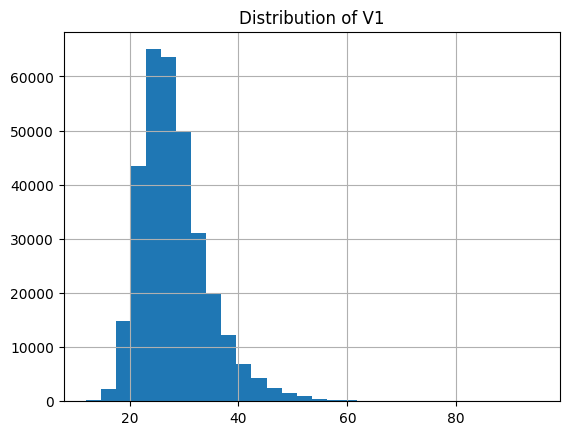

Here the distribution of the variable V5:


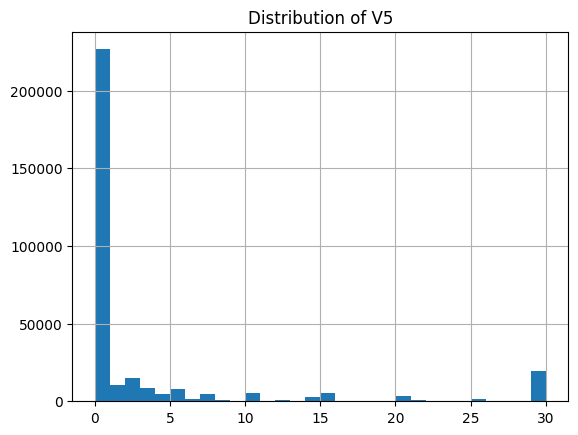

Here the distribution of the variable V6:


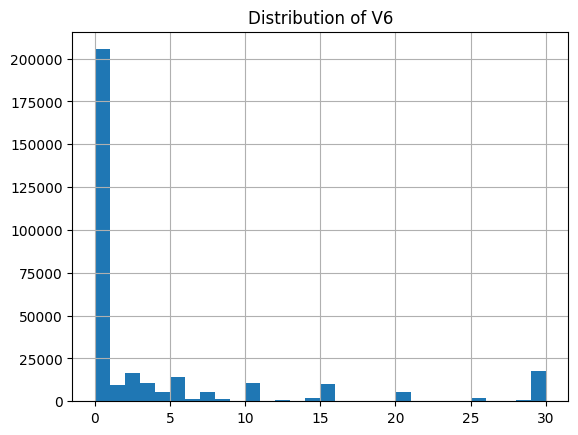

Here the distribution of the variable V10:


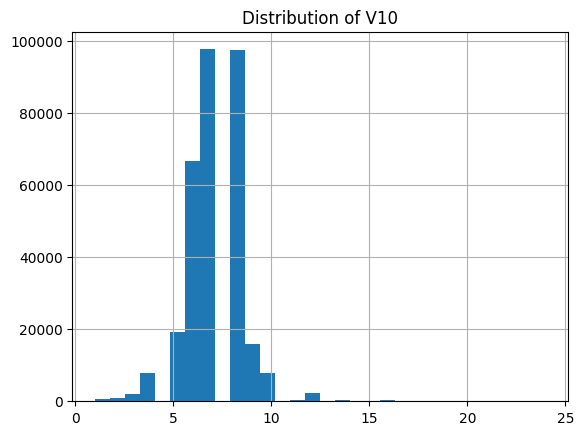

In [ ]:
# Now, I see the distribution of the continuos variables.
# V1
graf = df['V1'].hist(bins=30)
graf.set_title('Distribution of V1')
print("Here the distribution of the variable V1:")
plt.show()

# V5
graf5 = df['V5'].hist(bins=30)
graf5.set_title('Distribution of V5')
print("Here the distribution of the variable V5:")
plt.show()

# V6
graf6 = df['V6'].hist(bins=30)
graf6.set_title('Distribution of V6')
print("Here the distribution of the variable V6:")
plt.show()

# V10
graf10 = df['V10'].hist(bins=30)
graf10.set_title('Distribution of V10')
print("Here the distribution of the variable V10:")
plt.show()

### Pre processing

From the information obtained, it can be noted that the variables do not have missing values. In addition, there may be some extreme values, however, not knowing the nature of the dataset, I decided not to touch them. The main thing to note is that there are several categorical variables, which must be transformed in order for the neural network to work at its best. Furthermore, the continuous variables must be standardized.
I prefer to do these things after I have split the dataset, so that I can fit the transformation only on the training data and then apply it to the rest of the data, thus avoiding any possible leakage.


In [ ]:
# I transform the target.
y = y.map({'No': 0, 'Yes': 1})

In [ ]:
# Now, i divide the dataset.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
print("Here is the shape of the training set (only the X):")
print(X_train.shape)
print("Here is the shape of the test set (only the X):")
print(X_test.shape)

Here is the shape of the training set (only the X):
(223856, 17)
Here is the shape of the test set (only the X):
(95939, 17)


In [ ]:
# I define the continuos variables and then I standardize them.
continue_cols = ['V1', 'V5', 'V6', 'V10']

scaler = StandardScaler()
X_train[continue_cols] = scaler.fit_transform(X_train[continue_cols])
X_test[continue_cols] = scaler.transform(X_test[continue_cols])

In [ ]:
# I see the results
print('Standardized training set:')
X_train.head(10)

Standardized training set:


,V1,V2,V3,V4,V5,V6,V7,Sex,AgeCategory,Race,V8,V9,GenHealth,V10,V11,V12,V13
21568,-0.768254,Yes,No,No,-0.424410,-0.365854,No,Female,65-69,White,No,Yes,Good,-0.068535,No,No,No
140241,-0.820216,No,No,No,-0.424410,-0.491208,No,Male,60-64,White,No,No,Excellent,-0.068535,No,No,No
54873,1.132294,No,No,No,-0.173098,-0.365854,No,Female,75-79,Black,No,Yes,Good,-0.068535,No,No,No
20145,-1.028064,No,No,No,-0.424410,-0.491208,No,Female,50-54,White,Yes (during pregnancy),Yes,Excellent,0.628127,No,No,No
185759,3.034416,Yes,No,No,3.345265,2.015858,Yes,Male,45-49,White,No,Yes,Poor,-0.765196,No,No,No
216554,-0.280126,No,No,No,-0.424410,-0.491208,No,Male,55-59,White,No,Yes,Very good,-3.551844,No,No,No
312023,-0.867454,No,No,No,-0.424410,0.010206,No,Female,70-74,White,No,Yes,Very good,0.628127,No,No,No
93012,-0.020317,No,No,No,-0.424410,0.010206,No,Female,45-49,White,No,Yes,Good,0.628127,No,No,No
149384,-0.350984,No,No,No,-0.424410,-0.491208,No,Female,80 or older,White,No,No,Good,-1.461858,No,Yes,Yes
703,-0.777701,No,No,Yes,3.345265,-0.491208,Yes,Female,80 or older,White,No,No,Fair,-1.461858,No,No,Yes


In [ ]:
print('Standardized test set:')
X_test.head(10)

Standardized test set:


,V1,V2,V3,V4,V5,V6,V7,Sex,AgeCategory,Race,V8,V9,GenHealth,V10,V11,V12,V13
95846,-0.828089,No,No,No,0.078213,0.010206,No,Male,25-29,White,No,Yes,Excellent,1.324789,No,No,No
67884,0.242642,No,No,No,-0.424410,0.762325,No,Male,45-49,Hispanic,No,Yes,Good,0.628127,Yes,No,No
105707,0.003302,No,No,No,-0.173098,-0.240501,Yes,Female,80 or older,White,Yes,No,Good,-0.765196,No,No,No
201167,0.127696,Yes,No,No,-0.424410,-0.491208,Yes,Male,60-64,Hispanic,Yes,Yes,Very good,0.628127,No,No,No
193709,1.585780,No,No,No,-0.424410,-0.115148,No,Male,18-24,Hispanic,No,Yes,Good,-0.068535,No,No,No
70862,-0.528914,No,No,No,-0.424410,0.135559,No,Female,40-44,White,No,Yes,Very good,-0.765196,No,No,No
94774,2.369933,Yes,No,No,-0.173098,1.263738,No,Male,30-34,Black,Yes,No,Fair,-1.461858,No,No,No
204622,2.262860,No,No,No,3.345265,-0.491208,Yes,Female,55-59,White,No,Yes,Fair,-0.068535,No,No,No
32893,-0.768254,No,No,No,-0.424410,-0.491208,No,Female,18-24,White,No,Yes,Very good,-0.068535,Yes,No,No
217118,-0.051809,No,No,No,-0.424410,-0.365854,No,Female,50-54,White,No,Yes,Very good,0.628127,No,No,No


In [ ]:
X_train.describe()

,V1,V5,V6,V10
count,2.238560e+05,2.238560e+05,2.238560e+05,2.238560e+05
mean,1.306303e-15,-4.491360e-17,-1.468024e-17,-1.359152e-16
std,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00
min,-2.566452e+00,-4.244100e-01,-4.912076e-01,-4.248506e+00
25%,-6.769268e-01,-4.244100e-01,-4.912076e-01,-7.651965e-01
50%,-1.573073e-01,-4.244100e-01,-4.912076e-01,-6.853463e-02
75%,4.930043e-01,-1.730984e-01,-1.151478e-01,6.281272e-01
max,1.047600e+01,3.345265e+00,3.269391e+00,1.177472e+01


In [ ]:
X_test.describe()

,V1,V5,V6,V10
count,95939.000000,95939.000000,95939.000000,95939.000000
mean,0.003344,-0.002450,-0.008449,-0.003021
std,1.002775,0.996897,0.990661,1.001367
min,-2.536535,-0.424410,-0.491208,-4.248506
25%,-0.675352,-0.424410,-0.491208,-0.765196
50%,-0.149434,-0.424410,-0.491208,-0.068535
75%,0.485131,-0.173098,-0.115148,0.628127
max,9.998891,3.345265,3.269391,11.774717


In [ ]:
# I identify the categorical variables
categorical_cols = [col for col in X.columns if col not in continue_cols]

# Apply one-hot encoding
X_train = pd.get_dummies(X_train, columns=categorical_cols)
X_test = pd.get_dummies(X_test, columns=categorical_cols)

# I align the columns of the training set and the test set
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [ ]:
# I see the results
X_train.info()
X_test.head(10)

<class 'pandas.core.frame.DataFrame'>
Index: 223856 entries, 21568 to 241203
Data columns (total 50 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   V1                                   223856 non-null  float64
 1   V5                                   223856 non-null  float64
 2   V6                                   223856 non-null  float64
 3   V10                                  223856 non-null  float64
 4   V2_No                                223856 non-null  bool   
 5   V2_Yes                               223856 non-null  bool   
 6   V3_No                                223856 non-null  bool   
 7   V3_Yes                               223856 non-null  bool   
 8   V4_No                                223856 non-null  bool   
 9   V4_Yes                               223856 non-null  bool   
 10  V7_No                                223856 non-null  bool   
 11  V7_Yes        

,V1,V5,V6,V10,V2_No,V2_Yes,V3_No,V3_Yes,V4_No,V4_Yes,...,GenHealth_Fair,GenHealth_Good,GenHealth_Poor,GenHealth_Very good,V11_No,V11_Yes,V12_No,V12_Yes,V13_No,V13_Yes
95846,-0.828089,0.078213,0.010206,1.324789,True,False,True,False,True,False,...,False,False,False,False,True,False,True,False,True,False
67884,0.242642,-0.424410,0.762325,0.628127,True,False,True,False,True,False,...,False,True,False,False,False,True,True,False,True,False
105707,0.003302,-0.173098,-0.240501,-0.765196,True,False,True,False,True,False,...,False,True,False,False,True,False,True,False,True,False
201167,0.127696,-0.424410,-0.491208,0.628127,False,True,True,False,True,False,...,False,False,False,True,True,False,True,False,True,False
193709,1.585780,-0.424410,-0.115148,-0.068535,True,False,True,False,True,False,...,False,True,False,False,True,False,True,False,True,False
70862,-0.528914,-0.424410,0.135559,-0.765196,True,False,True,False,True,False,...,False,False,False,True,True,False,True,False,True,False
94774,2.369933,-0.173098,1.263738,-1.461858,False,True,True,False,True,False,...,True,False,False,False,True,False,True,False,True,False
204622,2.262860,3.345265,-0.491208,-0.068535,True,False,True,False,True,False,...,True,False,False,False,True,False,True,False,True,False
32893,-0.768254,-0.424410,-0.491208,-0.068535,True,False,True,False,True,False,...,False,False,False,True,False,True,True,False,True,False
217118,-0.051809,-0.424410,-0.365854,0.628127,True,False,True,False,True,False,...,False,False,False,True,True,False,True,False,True,False


In [ ]:
y_test.head()

,Target
95846,0
67884,0
105707,0
201167,0
193709,0


In [ ]:
y_train.head()

,Target
21568,0
140241,0
54873,0
20145,0
185759,0


### Model

All the preliminary operations have been done, as well as the pre-processing phase. At this point, I can focus more on the definition and training of the model.

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=7,
    mode='max',
    restore_best_weights=True
)

In [ ]:
# I define the neural network
input_layer = Input(shape=(50, ))
x = Dense(256, activation = 'relu')(input_layer)
x = Dense(256, activation = 'relu')(x)
x = Dense(256, activation = 'relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Dense(128, activation = 'relu')(x)
x = Dense(128, activation = 'relu')(x)
x = Dense(128, activation = 'relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Dense(64, activation = 'relu')(x)
x = Dense(64, activation = 'relu')(x)
x = Dense(64, activation = 'relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Dense(32, activation = 'relu')(x)
x = Dense(32, activation = 'relu')(x)
x = Dense(32, activation = 'relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Dense(16, activation = 'relu')(x)
x = Dense(16, activation = 'relu')(x)
x = Dense(16, activation = 'relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

output_layer = Dense(1, activation = 'sigmoid')(x)

model = Model(inputs = input_layer, outputs = output_layer)

In [ ]:
model.compile(optimizer = 'adam',
              metrics = ['accuracy', Recall(), AUC()],
              loss = 'binary_crossentropy')

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │        13,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 16)             │           27

 Total params: 234,401 (915.63 KB)

 Trainable params: 233,409 (911.75 KB)

 Non-trainable params: 992 (3.88 KB)

In [ ]:
history = model.fit(X_train, y_train, epochs = 15, batch_size = 32, validation_data = (X_test, y_test),
                    callbacks=[early_stopping])

Epoch 1/15
6996/6996 ━━━━━━━━━━━━━━━━━━━━ 50s 6ms/step - accuracy: 0.8687 - auc_1: 0.6208 - loss: 0.3513 - recall_1: 0.0711 - val_accuracy: 0.9145 - val_auc_1: 0.8378 - val_loss: 0.2319 - val_recall_1: 9.7418e-04
Epoch 2/15
6996/6996 ━━━━━━━━━━━━━━━━━━━━ 44s 6ms/step - accuracy: 0.9144 - auc_1: 0.8192 - loss: 0.2368 - recall_1: 0.0221 - val_accuracy: 0.9161 - val_auc_1: 0.8377 - val_loss: 0.2349 - val_recall_1: 0.0745
Epoch 3/15
6996/6996 ━━━━━━━━━━━━━━━━━━━━ 44s 6ms/step - accuracy: 0.9137 - auc_1: 0.8213 - loss: 0.2365 - recall_1: 0.0233 - val_accuracy: 0.9153 - val_auc_1: 0.8408 - val_loss: 0.2267 - val_recall_1: 0.0190
Epoch 4/15
6996/6996 ━━━━━━━━━━━━━━━━━━━━ 45s 6ms/step - accuracy: 0.9140 - auc_1: 0.8247 - loss: 0.2346 - recall_1: 0.0320 - val_accuracy: 0.9146 - val_auc_1: 0.8408 - val_loss: 0.2277 - val_recall_1: 0.0038
Epoch 5/15
6996/6996 ━━━━━━━━━━━━━━━━━━━━ 44s 6ms/step - accuracy: 0.9133 - auc_1: 0.8286 - loss: 0.2344 - recall_1: 0.0307 - val_accuracy: 0.9149 - val_auc_1: 

### Model evaluation.

Once the neural network is trained, it can be evaluated. To do this I plot the accuracy and loss, as well as the ROC curve. I also print the sensitivity, i.e. the recall

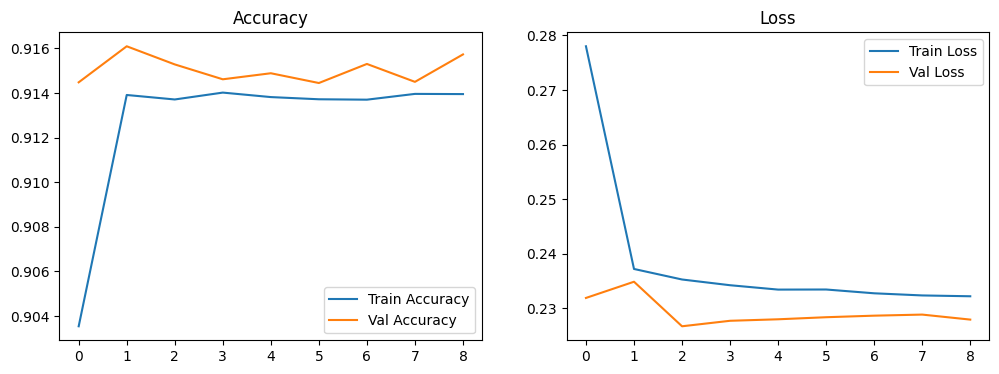

In [ ]:
# I plot the metrics
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()

2999/2999 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


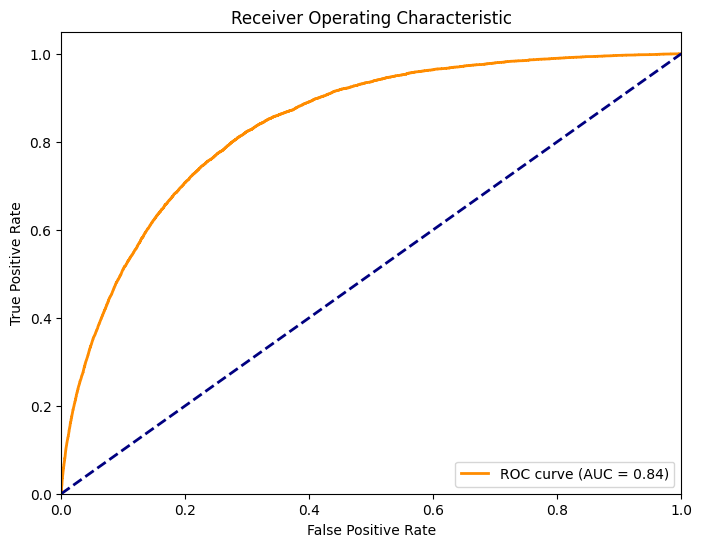

In [ ]:
# I do the predictions
y_pred_prob = model.predict(X_test)

# I compute the ROC and the AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


In [ ]:
# Final evaluation of the model
test_loss, test_accuracy, test_recall, test_auc = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")
print(f"Test Recall: {test_recall}")
print(f"Test AUC: {test_auc}")

2999/2999 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9160 - auc_1: 0.8394 - loss: 0.2340 - recall_1: 0.0729
Test Loss: 0.2348937839269638
Test Accuracy: 0.9160925149917603
Test Recall: 0.07452508807182312
Test AUC: 0.8377471566200256


### Final comments (1 of 2)

The model made may seem like a good model, but it is not. The accuracy is in fact higher than 0.9, while the area under the ROC curve is higher than 0.8 (generally speaking, values ​​higher than 0.8 are good, but not excellent). This indicates that we probably could have obtained a better result, perhaps using a much more complex network. But, despite this, our model is bad. Why? Well, this is because, the recall (sensitivity) is almost zero. This means that many of the instances that should be classified as positive, are actually classified as negative. Consequently, the model is not good. All this is caused by the target variable, which is very unbalanced. So, another change I will make is to associate weights to the classes, giving a much greater weight to the minority class (in terms of error).

In [ ]:
print("Target distribution:")
print(df['Target'].value_counts(normalize=True))

Target distribution:
Target
No     0.914405
Yes    0.085595
Name: proportion, dtype: float64


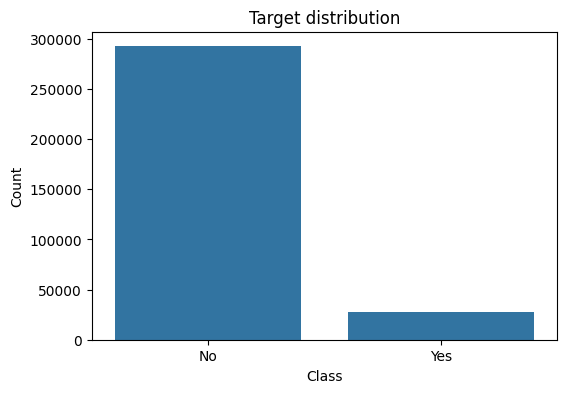

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Target', data=df)
plt.title('Target distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [ ]:
# I compute the classes weight
classes = np.unique(y_train)
class_weights_array = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights_array))

In [ ]:
# I define the neural network
input_layer = Input(shape=(50, ))
x = Dense(256, activation = 'relu')(input_layer)
x = Dense(256, activation = 'relu')(x)
x = Dense(256, activation = 'relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Dense(128, activation = 'relu')(x)
x = Dense(128, activation = 'relu')(x)
x = Dense(128, activation = 'relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Dense(64, activation = 'relu')(x)
x = Dense(64, activation = 'relu')(x)
x = Dense(64, activation = 'relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Dense(32, activation = 'relu')(x)
x = Dense(32, activation = 'relu')(x)
x = Dense(32, activation = 'relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Dense(16, activation = 'relu')(x)
x = Dense(16, activation = 'relu')(x)
x = Dense(16, activation = 'relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

output_layer = Dense(1, activation = 'sigmoid')(x)

model2 = Model(inputs = input_layer, outputs = output_layer)

In [ ]:
model2.compile(optimizer = 'adam',
              metrics = ['accuracy', Recall(), AUC()],
              loss = 'binary_crossentropy')

model2.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 256)            │        13,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 16)             │           27

 Total params: 234,401 (915.63 KB)

 Trainable params: 233,409 (911.75 KB)

 Non-trainable params: 992 (3.88 KB)

In [ ]:
history2 = model2.fit(X_train, y_train, epochs = 15, batch_size = 32, validation_data = (X_test, y_test), class_weight=class_weight_dict,
                    callbacks=[early_stopping])

Epoch 1/15
6996/6996 ━━━━━━━━━━━━━━━━━━━━ 52s 7ms/step - accuracy: 0.6185 - auc_2: 0.7094 - loss: 0.6324 - recall_2: 0.7090 - val_accuracy: 0.7668 - val_auc_2: 0.8367 - val_loss: 0.4474 - val_recall_2: 0.7450
Epoch 2/15
6996/6996 ━━━━━━━━━━━━━━━━━━━━ 45s 6ms/step - accuracy: 0.7212 - auc_2: 0.8167 - loss: 0.5261 - recall_2: 0.7817 - val_accuracy: 0.7358 - val_auc_2: 0.8396 - val_loss: 0.4779 - val_recall_2: 0.7942
Epoch 3/15
6996/6996 ━━━━━━━━━━━━━━━━━━━━ 44s 6ms/step - accuracy: 0.7203 - auc_2: 0.8220 - loss: 0.5172 - recall_2: 0.7961 - val_accuracy: 0.7318 - val_auc_2: 0.8370 - val_loss: 0.5306 - val_recall_2: 0.7983
Epoch 4/15
6996/6996 ━━━━━━━━━━━━━━━━━━━━ 45s 6ms/step - accuracy: 0.7298 - auc_2: 0.8252 - loss: 0.5139 - recall_2: 0.7967 - val_accuracy: 0.7424 - val_auc_2: 0.8393 - val_loss: 0.5140 - val_recall_2: 0.7847
Epoch 5/15
6996/6996 ━━━━━━━━━━━━━━━━━━━━ 45s 6ms/step - accuracy: 0.7272 - auc_2: 0.8286 - loss: 0.5103 - recall_2: 0.7969 - val_accuracy: 0.7230 - val_auc_2: 0.84

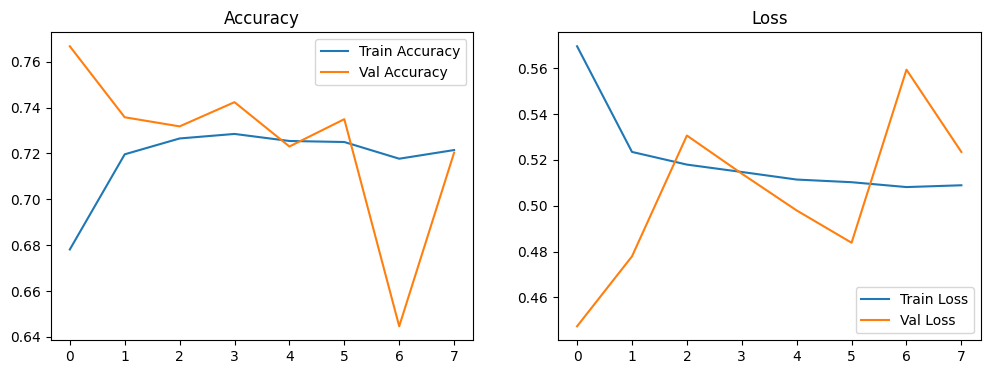

In [ ]:
# I plot the metrics
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history2.history['accuracy'], label='Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()

2999/2999 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


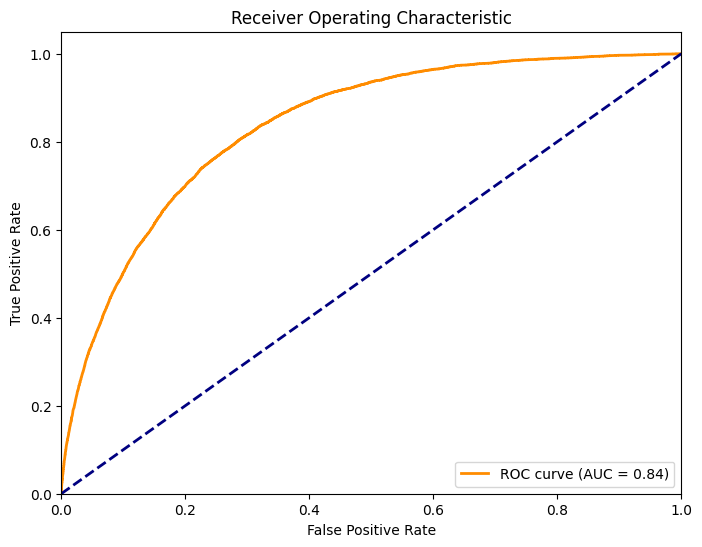

In [ ]:
# I do the predictions
y_pred_prob2 = model2.predict(X_test)

# I compute the ROC and the AUC
fpr2, tpr2, thresholds2 = roc_curve(y_test, y_pred_prob2)
roc_auc2 = auc(fpr2, tpr2)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr2, tpr2, color='darkorange', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc2)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

In [ ]:
# Final evaluation of the model
test_loss2, test_accuracy2, test_recall2, test_auc2 = model2.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss2}")
print(f"Test Accuracy: {test_accuracy2}")
print(f"Test Recall: {test_recall2}")
print(f"Test AUC: {test_auc2}")

2999/2999 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7683 - auc_2: 0.8387 - loss: 0.4462 - recall_2: 0.7518
Test Loss: 0.4474171996116638
Test Accuracy: 0.7667684555053711
Test Recall: 0.745007336139679
Test AUC: 0.8366913795471191


### Final comments (2 of 2)

As we can see, we now have a model with a lower accuracy than before (it is now 70%), but a much higher sensitivity. This means that the model classifies positive instances better than before, which were previously classified as negative. The model is now good, but not excellent. In fact, an accuracy of 70% cannot be considered excellent, since this means that the model correctly classifies only 70% of the observations. In any case, I believe it is better than the previous model, which classified negative instances well, but not positive ones. This is because, depending on the nature of the dataset, especially medical ones, it is unlikely that a class is unimportant enough to be neglected, which is why it is good to balance the classes and make sure that the model does not discriminate between them.